<a href="https://colab.research.google.com/github/Integenpiyush/financial-sentiment-bilstm-bert/blob/main/notebooks/02_bilstm_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install transformers datasets wandb -q

import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle

# Load preprocessed data
with open('/content/preprocessed_data.pkl', 'rb') as f:
    data = pickle.load(f)

X_train_pad = data['X_train_pad']
X_test_pad = data['X_test_pad']
y_train = data['y_train']
y_test = data['y_test']
class_weight_dict = data['class_weight_dict']
tokenizer = data['tokenizer']
label_classes = data['label_classes']
VOCAB_SIZE = data['vocab_size']
MAX_LEN = data['max_len']

print("Data loaded successfully")
print("X_train_pad shape:", X_train_pad.shape)
print("X_test_pad shape:", X_test_pad.shape)
print("Classes:", label_classes)

Data loaded successfully
X_train_pad shape: (1811, 50)
X_test_pad shape: (453, 50)
Classes: ['negative', 'neutral', 'positive']


In [4]:
data

{'X_train_pad': array([[1703, 1704, 1074, ...,    0,    0,    0],
        [2512,   11, 2513, ...,    0,    0,    0],
        [   2,  793,  229, ...,    0,    0,    0],
        ...,
        [   2,   48, 5451, ...,    0,    0,    0],
        [   2,   84,  154, ...,    0,    0,    0],
        [   2,   84,  418, ...,    0,    0,    0]], dtype=int32),
 'X_test_pad': array([[   2,   14,   11, ...,    0,    0,    0],
        [ 742,   11,  342, ...,    0,    0,    0],
        [   4,  118, 3168, ...,    0,    0,    0],
        ...,
        [   2, 1605,  152, ...,    0,    0,    0],
        [   4,  231,   37, ...,    0,    0,    0],
        [1195,    9,  899, ...,    0,    0,    0]], dtype=int32),
 'y_train': array([2, 1, 1, ..., 1, 1, 1]),
 'y_test': array([2, 1, 0, 1, 2, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 2, 1, 1, 0, 1, 1,
        2, 0, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 1, 2, 1, 1, 1, 2, 1, 2, 2,
        2, 2, 1, 1, 1, 1, 1, 1, 2, 2, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1,
        1, 2, 1, 1, 1, 1, 0

## Day 5 — Bi-LSTM Architecture

Why Bi-LSTM over simple LSTM?
- Regular LSTM reads left to right only
- Bi-LSTM reads BOTH directions — left to right AND right to left
- For "profit rose despite challenges" — understanding "despite"
  requires knowing what comes after it too
- Bidirectional context is critical for sentiment — a word's
  meaning often depends on what follows it

In [5]:
from tensorflow.keras.utils import to_categorical

y_train_cat = to_categorical(y_train, num_classes=3)
y_test_cat = to_categorical(y_test, num_classes=3)

print("y_train_cat shape:", y_train_cat.shape)
print("Example label:", y_train[0], "-> one-hot:", y_train_cat[0])

y_train_cat shape: (1811, 3)
Example label: 2 -> one-hot: [0. 0. 1.]


In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, Bidirectional, LSTM, Dense,
    Dropout, SpatialDropout1D
)

EMBEDDING_DIM = 100

model = Sequential([
    Embedding(input_dim=VOCAB_SIZE,
              output_dim=EMBEDDING_DIM,
              input_shape=(MAX_LEN,)),
    SpatialDropout1D(0.3),
    Bidirectional(LSTM(64, return_sequences=True)),
    Bidirectional(LSTM(32)),
    Dense(64, activation='relu'),
    Dropout(0.4),
    Dense(3, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:103: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 50, 100)        │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 50, 100)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 50, 128)        │        84,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,130,051 (4.31 MB)

 Trainable params: 1,130,051 (4.31 MB)

 Non-trainable params: 0 (0.00 B)

## Architecture Explanation

1. Embedding(10000, 100): converts word indices to 100-dim
   dense vectors. Learned during training — words with
   similar meaning end up with similar vectors.

2. SpatialDropout1D(0.3): drops entire embedding dimensions
   randomly, not individual values — better regularization
   for sequence data than standard Dropout.

3. Bidirectional(LSTM(64, return_sequences=True)):
   first BiLSTM layer, outputs full sequence (needed because
   we stack another LSTM after it). 64 units x 2 directions =
   128-dim output per timestep.

4. Bidirectional(LSTM(32)): second BiLSTM layer, outputs
   only final hidden state (return_sequences=False, default) —
   summarizes entire sentence into one vector.

5. Dense(64, relu) + Dropout(0.4): standard feedforward
   layer with regularization to prevent overfitting.

6. Dense(3, softmax): output layer — 3 classes, softmax
   gives probability distribution summing to 1.

In [7]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully")
print(f"\nTotal parameters: {model.count_params():,}")

Model compiled successfully

Total parameters: 1,130,051


## Why categorical_crossentropy + softmax?
- 3-class classification, mutually exclusive (one sentiment per sentence)
- softmax converts raw outputs to probabilities summing to 1
- categorical_crossentropy measures distance between
  predicted probability distribution and true one-hot label

## Why Adam optimizer?
- Adapts learning rate per parameter automatically
- Combines momentum (RMSprop-style) with adaptive learning rates
- Default choice for most deep learning tasks —
  rarely needs manual tuning unlike plain SGD

## Day 5 — Architecture Summary

Total Parameters: 1,130,051
- Embedding layer: 1,000,000 params (88.5% of total)
  This is expected — vocab_size(10000) × embedding_dim(100)
- BiLSTM layers: 125,696 params combined
- Dense layers: 4,355 params

Output shapes confirm architecture:
- Embedding: (50, 100) — each word becomes 100-dim vector
- First BiLSTM: (50, 128) — 64 units × 2 directions, full sequence
- Second BiLSTM: (64,) — 32 units × 2 directions, final state only
- Final output: (3,) — probability distribution over 3 classes

Note: With only 1,811 training samples and 1.13M parameters,
overfitting risk is high. Dropout (0.3 + 0.4) and early stopping
will be critical during training.

## Day 6 — Model Training
Training Bi-LSTM with class weights and early stopping.

In [8]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_bilstm_model.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

print("Callbacks configured")
print("EarlyStopping patience: 5 epochs")
print("Will restore best weights automatically")

Callbacks configured
EarlyStopping patience: 5 epochs
Will restore best weights automatically


## Why EarlyStopping?
With only 1,811 training samples, the model will start
memorizing training data after a certain point. EarlyStopping
monitors validation loss — if it doesn't improve for 5
consecutive epochs, training stops and best weights are restored.
This prevents wasting compute and prevents overfitting.

## Why ModelCheckpoint?
Saves the model with lowest validation loss to disk,
even if later epochs perform worse. Combined with
restore_best_weights in EarlyStopping, this is a safety net.

In [9]:
history = model.fit(
    X_train_pad, y_train_cat,
    validation_split=0.15,
    epochs=30,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

Epoch 1/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4753 - loss: 1.0783
Epoch 1: val_loss improved from None to 0.77584, saving model to best_bilstm_model.keras

Epoch 1: finished saving model to best_bilstm_model.keras
49/49 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.5211 - loss: 1.0620 - val_accuracy: 0.6728 - val_loss: 0.7758
Epoch 2/30
47/49 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7135 - loss: 0.8122
Epoch 2: val_loss improved from 0.77584 to 0.64098, saving model to best_bilstm_model.keras

Epoch 2: finished saving model to best_bilstm_model.keras
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.7167 - loss: 0.7874 - val_accuracy: 0.6801 - val_loss: 0.6410
Epoch 3/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7366 - loss: 0.6628
Epoch 3: val_loss improved from 0.64098 to 0.60687, saving model to best_bilstm_model.keras

Epoch 3: finished saving model to best_bilstm_model.keras
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.7570 - l

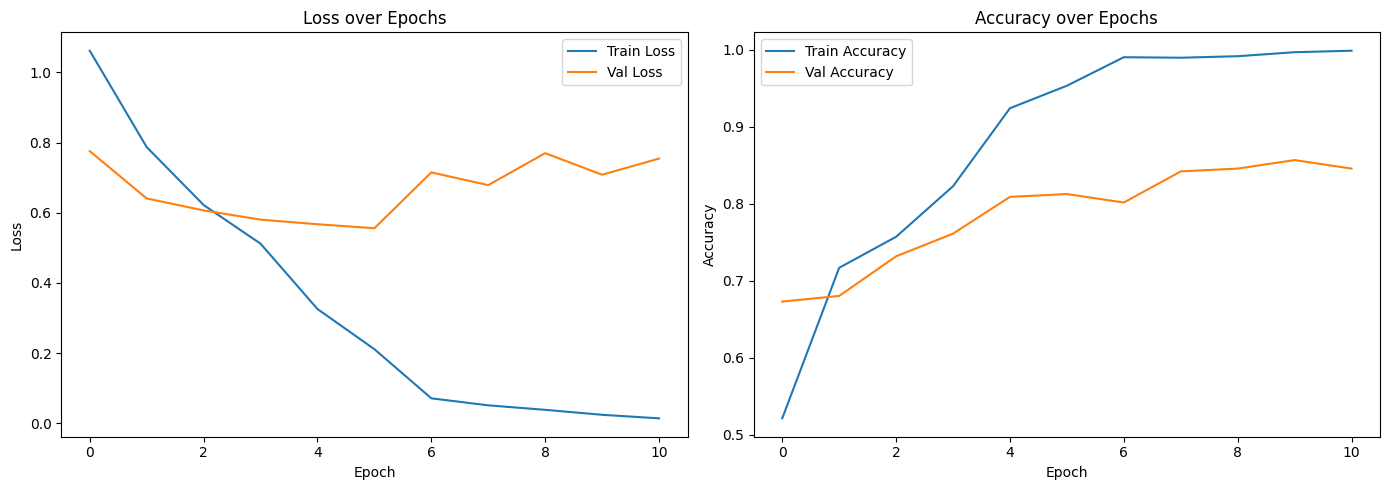

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Accuracy over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig('bilstm_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

## Day 6 — Training Results & Overfitting Analysis

Training stopped at epoch 11 (EarlyStopping triggered)
Best epoch: 6 — weights restored automatically

Best Epoch (6) Metrics:
- Train accuracy: 95.3% | Train loss: 0.211
- Val accuracy: 81.25% | Val loss: 0.556

Overfitting Pattern Observed:
- Epochs 1-6: both train and val loss decreasing — healthy learning
- Epochs 7-11: train loss collapsed to 0.01-0.07 (near perfect)
  while val loss INCREASED to 0.70-0.77
- Train accuracy hit 99%+ while val accuracy plateaued at 84-85%
- Classic overfitting signature — model memorizing training
  examples rather than learning generalizable patterns

Why this happened:
- Only 1,811 training samples vs 1.13M parameters
- Severe parameter-to-data ratio enables memorization
- Dropout (0.3, 0.4) slowed but did not prevent overfitting

EarlyStopping + ModelCheckpoint correctly intervened:
- Training continued 5 more epochs after best point (patience=5)
- Best weights (epoch 6) automatically restored
- Final model uses epoch 6 weights, not epoch 11

In [11]:
from sklearn.metrics import (classification_report,
                              confusion_matrix, f1_score,
                              accuracy_score)

y_pred_probs = model.predict(X_test_pad)
y_pred = np.argmax(y_pred_probs, axis=1)

print("Test Set Performance (Epoch 6 weights):")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"F1 Macro: {f1_score(y_test, y_pred, average='macro'):.4f}")
print(f"F1 Weighted: {f1_score(y_test, y_pred, average='weighted'):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred,
                             target_names=label_classes))

15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 183ms/step
Test Set Performance (Epoch 6 weights):
Accuracy: 0.8366
F1 Macro: 0.8030
F1 Weighted: 0.8428

Classification Report:
              precision    recall  f1-score   support

    negative       0.79      0.74      0.76        61
     neutral       0.97      0.84      0.90       278
    positive       0.65      0.88      0.75       114

    accuracy                           0.84       453
   macro avg       0.80      0.82      0.80       453
weighted avg       0.86      0.84      0.84       453



## Day 6 — Final Test Results (Best Epoch 6 Weights)

Overall Performance:
- Accuracy: 83.66%
- F1 Macro: 0.8030 (unweighted average across classes —
  fair representation of minority class performance)
- F1 Weighted: 0.8428 (weighted by class frequency)

Per-Class Breakdown:

| Class    | Precision | Recall | F1   | Support |
|----------|-----------|--------|------|---------|
| Negative | 0.79      | 0.74   | 0.76 | 61      |
| Neutral  | 0.97      | 0.84   | 0.90 | 278     |
| Positive | 0.65      | 0.88   | 0.75 | 114     |

Key Observations:

1. Neutral has highest precision (0.97) but only 84% recall
   — model is very confident when predicting neutral, but
   misses 16% of actual neutral cases (likely confusing
   them with positive/negative)

2. Positive has LOWEST precision (0.65) but HIGHEST recall (0.88)
   — model over-predicts positive class, catching most true
   positives but also misclassifying many neutral/negative
   sentences as positive

3. Negative is most balanced (0.79 precision, 0.74 recall)
   despite being the rarest class (61 samples) — class weights
   (2.494x) successfully helped minority class performance

4. F1 Macro (0.80) is meaningfully lower than F1 Weighted (0.84)
   — confirms the model performs less well on minority classes
   than the weighted average suggests; macro is the honest metric

Business Interpretation:
Model is biased toward predicting "positive" — likely
over-fires on financial growth-language even in neutral
contexts. This matches the EDA finding that "rose", "increased",
"growth" words appear distinctly in positive class — the model
may be over-indexing on these surface words rather than
full context. This is the exact problem DistilBERT's deeper
contextual understanding should solve.

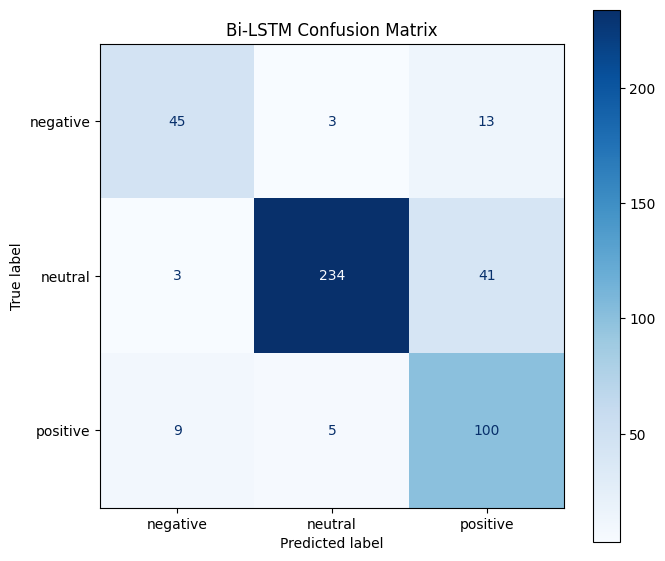

In [12]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=label_classes)
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Bi-LSTM Confusion Matrix')
plt.tight_layout()
plt.savefig('bilstm_confusion_matrix.png', dpi=150,
            bbox_inches='tight')
plt.show()

## Confusion Matrix Analysis

|              | Pred: Negative | Pred: Neutral | Pred: Positive |
|--------------|-----------------|----------------|-----------------|
| True Negative| 45              | 3              | 13              |
| True Neutral | 3               | 234            | 41              |
| True Positive| 9               | 5              | 100             |

Key Error Pattern Confirmed:
- 41 neutral sentences misclassified as POSITIVE (largest single error)
- 13 negative sentences misclassified as POSITIVE
- Only 3 neutral sentences misclassified as negative
- Total positive over-prediction: 41+13 = 54 sentences wrongly
  pulled toward "positive"

Root Cause Hypothesis:
Financial neutral statements often contain growth-adjacent
language even when not expressing investor sentiment:
e.g. "Company plans to grow its market presence in Russia"
— contains "grow" but is a neutral factual statement, not
a positive sentiment about stock performance.

The Bi-LSTM, trained on only 1,811 examples, may be pattern-
matching on words like "grow", "increase", "expand" without
fully grasping when these words describe NEUTRAL business
plans versus POSITIVE financial outcomes.

This is the exact limitation transformer models like DistilBERT
are designed to solve — pretrained contextual embeddings
understand word meaning based on surrounding context, not
just word presence.

Diagonal correctness:
- Negative correctly classified: 45/61 (73.8%)
- Neutral correctly classified: 234/278 (84.2%)
- Positive correctly classified: 100/114 (87.7%)